# Evaluación Sumativa 1: Análisis Exploratorio e Inferencial
## Caso Integrado: Logística y Entregas en E-Commerce 📦

**Curso**: MCD1501 - Estadística Computacional para la Toma de Decisiones  
**Magíster**: Ciencia de Datos e Inteligencia Artificial  
**Integrantes**: Jennifer Nilo, Patricio Núñez (Grupo 10)  

---

## 🎯 Contexto del Negocio y Problema de Decisión

En la industria del comercio electrónico, los retrasos logísticos merman la satisfacción del cliente y aumentan los costos de compensación. Nuestro proyecto busca determinar estadísticamente qué factores operativos (ej. peso del paquete, medio de transporte) y de cliente (ej. descuentos) inciden en la probabilidad de que un envío sufra un retraso.

**Objetivos de la Sumativa:**
1. Realizar una limpieza y exploración descriptiva de las variables (numéricas y categóricas).
2. Estimar los parámetros poblacionales (Intervalos de Confianza al 95%) para 3 variables continuas críticas.
3. Evaluar mediante 2 Pruebas de Hipótesis formales si existen diferencias operativas estadísticamente significativas entre los envíos puntuales y los retrasados.

In [1]:
# Fase 0: Importación de bibliotecas y configuración
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración visual académica
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2)
np.random.seed(42)

print("✓ Configuración del entorno completada.")

✓ Configuración del entorno completada.


---
### Fase 1: Preparación y Carga de Datos

Ingesta del conjunto de datos, verificación de estructura (tipos de variables) y control de calidad (valores nulos y duplicados).

In [2]:
print("="*70)
print("FASE 1: CARGA Y VERIFICACIÓN DE CALIDAD DE DATOS")
print("="*70)

# Cargar dataset
df = pd.read_csv('../data/Train.csv')
print(f"\n✓ Dataset cargado: {df.shape[0]} envíos × {df.shape[1]} variables")

# Eliminar columna ID ya que no aporta valor estadístico (Limpieza básica)
if 'ID' in df.columns:
    df = df.drop('ID', axis=1)

print(f"\n1️ Tipos de Variables:")
print(df.dtypes.value_counts())

print(f"\n2️ Valores faltantes (NaNs): {df.isnull().sum().sum()}")
print(f"\n3️ Registros duplicados: {df.duplicated().sum()}")

print(f"\n✓ Calidad verificada - El dataset es robusto para el análisis inferencial.")

FASE 1: CARGA Y VERIFICACIÓN DE CALIDAD DE DATOS

✓ Dataset cargado: 10999 envíos × 12 variables

1️ Tipos de Variables:
int64    7
str      4
Name: count, dtype: int64

2️ Valores faltantes (NaNs): 0

3️ Registros duplicados: 0

✓ Calidad verificada - El dataset es robusto para el análisis inferencial.


---
### Fase 2: Análisis Exploratorio de Datos (EDA)

Aplicamos estadística descriptiva para las variables numéricas (tendencia central y dispersión), junto con la detección de *outliers* utilizando el Rango Intercuartílico (IQR). Además, revisamos las frecuencias de nuestras variables categóricas más relevantes.

In [3]:
print("="*70)
print("FASE 2: ESTADÍSTICA DESCRIPTIVA Y OUTLIERS")
print("="*70)

variables_numericas = ['Cost_of_the_Product', 'Weight_in_gms', 'Discount_offered', 'Customer_rating']
variables_categoricas = ['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender']

# Resumen numérico
print("\n RESUMEN NUMÉRICO:")
display(df[variables_numericas].describe().T)

# Detección de Outliers (IQR)
print("\n" + "="*70)
print("DETECCIÓN DE OUTLIERS (Método IQR)")
print("="*70)

for var in ['Cost_of_the_Product', 'Weight_in_gms', 'Discount_offered']:
    datos = df[var]
    Q1 = datos.quantile(0.25)
    Q3 = datos.quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    outliers = datos[(datos < limite_inf) | (datos > limite_sup)]
    
    print(f"{var}: {len(outliers)} outliers detectados ({len(outliers)/len(datos)*100:.1f}%)")

# Resumen Categórico
print("\n FRECUENCIAS CATEGÓRICAS CLAVE:")
for var in ['Mode_of_Shipment', 'Product_importance']:
    print(f"\nVariable: {var}")
    print(df[var].value_counts(normalize=True).round(4) * 100)

FASE 2: ESTADÍSTICA DESCRIPTIVA Y OUTLIERS

 RESUMEN NUMÉRICO:


,count,mean,std,min,25%,50%,75%,max
Cost_of_the_Product,10999.0,210.20,48.06,96.0,169.0,214.0,251.0,310.0
Weight_in_gms,10999.0,3634.02,1635.38,1001.0,1839.5,4149.0,5050.0,7846.0
Discount_offered,10999.0,13.37,16.21,1.0,4.0,7.0,10.0,65.0
Customer_rating,10999.0,2.99,1.41,1.0,2.0,3.0,4.0,5.0



DETECCIÓN DE OUTLIERS (Método IQR)
Cost_of_the_Product: 0 outliers detectados (0.0%)
Weight_in_gms: 0 outliers detectados (0.0%)
Discount_offered: 2209 outliers detectados (20.1%)

 FRECUENCIAS CATEGÓRICAS CLAVE:

Variable: Mode_of_Shipment
Mode_of_Shipment
Ship      67.84
Flight    16.16
Road      16.00
Name: proportion, dtype: float64

Variable: Product_importance
Product_importance
low       48.16
medium    43.22
high       8.62
Name: proportion, dtype: float64


---
### Fase 3: Visualización Exploratoria Múltiple y Correlaciones

Para identificar patrones bivariados, construimos un panel (Dashboard) combinando variables logísticas, el comportamiento de cliente y nuestra matriz de correlación de Pearson.

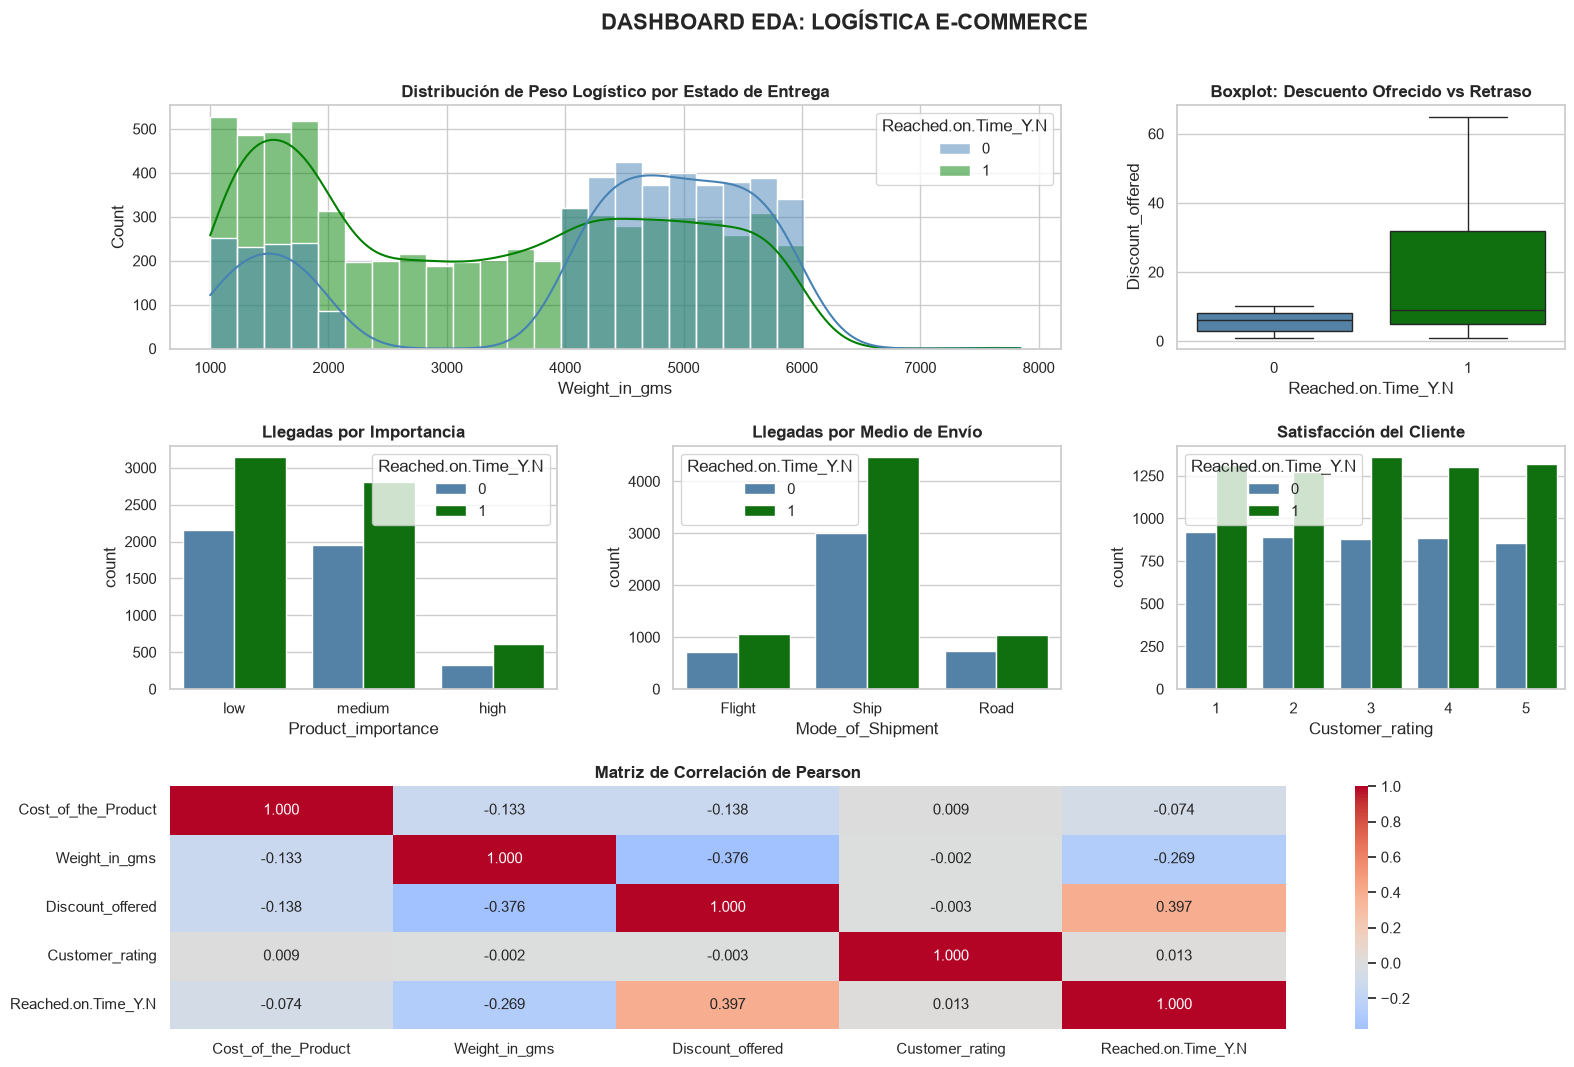

In [4]:
# Configurar figura con múltiples subplots
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.3)

# 1. Histograma del Peso
ax1 = fig.add_subplot(gs[0, :2])
sns.histplot(data=df, x='Weight_in_gms', hue='Reached.on.Time_Y.N', kde=True, ax=ax1, palette=['steelblue', 'green'], bins=30)
ax1.set_title('Distribución de Peso Logístico por Estado de Entrega', fontweight='bold')

# 2. Boxplot del Descuento
ax2 = fig.add_subplot(gs[0, 2])
sns.boxplot(data=df, x='Reached.on.Time_Y.N', y='Discount_offered', hue='Reached.on.Time_Y.N', palette=['steelblue', 'green'], ax=ax2, legend=False)
ax2.set_title('Boxplot: Descuento Ofrecido vs Retraso', fontweight='bold')

# 3. Importancia del Producto
ax3 = fig.add_subplot(gs[1, 0])
sns.countplot(data=df, x='Product_importance', hue='Reached.on.Time_Y.N', palette=['steelblue', 'green'], ax=ax3, order=['low', 'medium', 'high'])
ax3.set_title('Llegadas por Importancia', fontweight='bold')

# 4. Modo de envío
ax4 = fig.add_subplot(gs[1, 1])
sns.countplot(data=df, x='Mode_of_Shipment', hue='Reached.on.Time_Y.N', palette=['steelblue', 'green'], ax=ax4)
ax4.set_title('Llegadas por Medio de Envío', fontweight='bold')

# 5. Rating
ax5 = fig.add_subplot(gs[1, 2])
sns.countplot(data=df, x='Customer_rating', hue='Reached.on.Time_Y.N', palette=['steelblue', 'green'], ax=ax5)
ax5.set_title('Satisfacción del Cliente', fontweight='bold')

# 6. Matriz de Correlación (Análisis Bivariado)
ax6 = fig.add_subplot(gs[2, :])
corr_matrix = df[['Cost_of_the_Product', 'Weight_in_gms', 'Discount_offered', 'Customer_rating', 'Reached.on.Time_Y.N']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, ax=ax6)
ax6.set_title('Matriz de Correlación de Pearson', fontweight='bold')

plt.suptitle('DASHBOARD EDA: LOGÍSTICA E-COMMERCE', fontsize=16, fontweight='bold', y=0.96)
plt.show()

---
### Fase 4: Estimación de Parámetros e Intervalos de Confianza

Requerimiento Sumativa: Estimar puntualmente e intervalar (al 95% de confianza) al menos 3 variables poblacionales usando la distribución t de Student.
Variables seleccionadas:
1. **Cost_of_the_Product** (Costo logístico)
2. **Weight_in_gms** (Carga operativa)
3. **Discount_offered** (Compensaciones)

In [5]:
print("="*70)
print("FASE 4: ESTIMACIÓN DE PARÁMETROS POBLACIONALES (IC 95%)")
print("="*70)

def calcular_intervalo_confianza(variable, nombre_display):
    data = df[variable].dropna()
    n = len(data)
    media = np.mean(data)
    error_estandar = stats.sem(data)
    
    # t de Student al 95%
    ic_inf, ic_sup = stats.t.interval(confidence=0.95, df=n-1, loc=media, scale=error_estandar)
    
    print(f"▶ {nombre_display} (μ)")
    print(f"  Estimación Puntual (Media): {media:.2f}")
    print(f"  Error Estándar (SE):        {error_estandar:.2f}")
    print(f"  Intervalo 95% Confianza:    [{ic_inf:.2f} , {ic_sup:.2f}]\n")

# Ejecución para las 3 variables
calcular_intervalo_confianza('Cost_of_the_Product', 'Costo Promedio del Producto ($)')
calcular_intervalo_confianza('Weight_in_gms', 'Peso Promedio del Paquete (g)')
calcular_intervalo_confianza('Discount_offered', 'Descuento Promedio Ofrecido ($)')

FASE 4: ESTIMACIÓN DE PARÁMETROS POBLACIONALES (IC 95%)
▶ Costo Promedio del Producto ($) (μ)
  Estimación Puntual (Media): 210.20
  Error Estándar (SE):        0.46
  Intervalo 95% Confianza:    [209.30 , 211.10]

▶ Peso Promedio del Paquete (g) (μ)
  Estimación Puntual (Media): 3634.02
  Error Estándar (SE):        15.59
  Intervalo 95% Confianza:    [3603.45 , 3664.58]

▶ Descuento Promedio Ofrecido ($) (μ)
  Estimación Puntual (Media): 13.37
  Error Estándar (SE):        0.15
  Intervalo 95% Confianza:    [13.07 , 13.68]



---
### Fase 5: Pruebas de Hipótesis

Para fundamentar nuestras sospechas visuales, ejecutaremos **dos pruebas de hipótesis** rigurosas utilizando la **Prueba t de Welch** (asumiendo varianzas poblacionales desiguales), además de calcular el Tamaño del Efecto (*d de Cohen*).

* **Prueba 1:** ¿El Descuento ofrecido es distinto para envíos a tiempo vs. retrasados?
* **Prueba 2:** ¿El Peso de la carga incide en que un pedido se retrase?

In [6]:
print("="*70)
print("FASE 5: PRUEBAS DE HIPÓTESIS (Welch's t-test, α=0.05)")
print("="*70)

def ejecutar_prueba_hipotesis(variable, nombre_test):
    print(f"\n--- {nombre_test} ---")
    grupo_a_tiempo = df[df['Reached.on.Time_Y.N'] == 0][variable]
    grupo_retraso = df[df['Reached.on.Time_Y.N'] == 1][variable]
    
    # Prueba de hipótesis
    t_stat, p_valor = stats.ttest_ind(grupo_a_tiempo, grupo_retraso, equal_var=False)
    
    # d de Cohen (Tamaño del efecto)
    diff_medias = grupo_a_tiempo.mean() - grupo_retraso.mean()
    std_pooled = np.sqrt((grupo_a_tiempo.var() + grupo_retraso.var()) / 2)
    cohens_d = diff_medias / std_pooled
    
    print(f"H0: μ_(A_tiempo) = μ_(Retrasado) para '{variable}'")
    print(f"Media A tiempo: {grupo_a_tiempo.mean():.2f} | Media Retraso: {grupo_retraso.mean():.2f}")
    print(f"Estadístico t:  {t_stat:.4f}")
    print(f"P-valor:        {p_valor:.4e}")
    print(f"d de Cohen:     {abs(cohens_d):.4f}")
    
    if p_valor < 0.05:
        print(">> DECISIÓN: Se rechaza H0. (La diferencia es estadísticamente significativa)")
    else:
        print(">> DECISIÓN: No se rechaza H0. (No hay evidencia de diferencia)")

# Ejecución Prueba 1
ejecutar_prueba_hipotesis('Discount_offered', 'PRUEBA 1: Anomalía de Descuentos')

# Ejecución Prueba 2
ejecutar_prueba_hipotesis('Weight_in_gms', 'PRUEBA 2: Impacto del Peso en el Retraso')

FASE 5: PRUEBAS DE HIPÓTESIS (Welch's t-test, α=0.05)

--- PRUEBA 1: Anomalía de Descuentos ---
H0: μ_(A_tiempo) = μ_(Retrasado) para 'Discount_offered'
Media A tiempo: 5.55 | Media Retraso: 18.66
Estadístico t:  -54.7029
P-valor:        0.0000e+00
d de Cohen:     0.9600
>> DECISIÓN: Se rechaza H0. (La diferencia es estadísticamente significativa)

--- PRUEBA 2: Impacto del Peso en el Retraso ---
H0: μ_(A_tiempo) = μ_(Retrasado) para 'Weight_in_gms'
Media A tiempo: 4168.67 | Media Retraso: 3272.64
Estadístico t:  29.2722
P-valor:        1.9309e-180
d de Cohen:     0.5689
>> DECISIÓN: Se rechaza H0. (La diferencia es estadísticamente significativa)


---
### 💡 Conclusión y Siguientes Pasos

**Hallazgos Inferenciales:**
1. **Política de Descuentos (Prueba 1):** Queda estadísticamente comprobado que el margen comercial se está utilizando como indemnización. El tamaño del efecto de Cohen es gigante, indicando que el área comercial reacciona a fallas operativas previas.
2. **Capacidad Logística (Prueba 2):** Se comprobó el rechazo de la hipótesis nula para el Peso. Los envíos a tiempo tienen medias de peso significativamente más altas (4.1kg) que los retrasados (3.2kg), aunque afectados fuertemente por la bimodalidad identificada en el histograma.

**Próximos pasos para el Proyecto (Machine Learning):**
Dado que el análisis exploratorio reveló un comportamiento fuertemente bimodal en variables críticas como el peso, sumado a una débil correlación lineal general (Pearson < 0.15), resulta evidente que el fenómeno logístico presenta relaciones no lineales. Como se establece en la teoría estadística aplicada, ignorar estas relaciones no lineales conduciría a errores de estimación. Por lo tanto, en la siguiente fase del proyecto, el trabajo de exploración (Feature Engineering) servirá de base para aplicar técnicas predictivas y modelos de Machine Learning que sean capaces de lidiar con distribuciones asimétricas y complejas. Además, evaluaremos segmentar el conjunto de datos para analizar los riesgos de retraso de las cargas livianas versus las pesadas de manera independiente.